# 🤖 Unsupervised Machine Learning
## A Beginner-Friendly Classroom Guide
### Using the Credit Card Customer Dataset

---

> **Course:** Introduction to Machine Learning  
> **Topic:** Unsupervised Learning — K-Means Clustering & Principal Component Analysis (PCA)  
> **Dataset:** Credit Card Customer Segmentation (`CC_GENERAL.csv`)  
> **Real-world use case:** Grouping bank customers by spending behaviour for targeted marketing

---

### 📚 What You Will Learn in This Notebook

By the end of this notebook you will be able to:

1. **Explain** what Unsupervised Machine Learning is and when to use it
2. **Understand** the K-Means Clustering algorithm step-by-step
3. **Understand** Principal Component Analysis (PCA) and why it matters
4. **Apply** both algorithms to a real banking dataset
5. **Visualise and interpret** the results like a data scientist

---


---
## 🧠 Part 1 — What is Machine Learning?

**Machine Learning (ML)** is the science of teaching computers to learn patterns from data **without being explicitly programmed** for every rule.

Think of it like this:

| Traditional Programming | Machine Learning |
|--------------------------|-----------------|
| You write every rule | The computer learns the rules from data |
| `if balance > 10000: premium` | Algorithm discovers groups on its own |
| Rigid and manual | Flexible and scalable |

---

### The Three Types of Machine Learning

```
Machine Learning
├── Supervised Learning      → You provide labels (e.g., spam / not spam)
├── Unsupervised Learning    → No labels, the algorithm finds patterns itself
└── Reinforcement Learning   → Agent learns by trial and reward
```

---

## 🔍 Part 2 — What is Unsupervised Learning?

**Unsupervised Learning** means we give the algorithm data **without any labels or correct answers**. The algorithm must discover hidden structure all by itself.

### 🏦 Real-World Analogy

Imagine you are a bank manager. You have 9,000 customers with data on their:
- Credit card balance
- Purchase amounts
- Cash advances
- Payment history
- …and more

You want to **group similar customers together** so you can:
- Offer the right credit limit to the right people
- Target promotions to the right segment
- Identify risky customers early

You don't already know which group each customer belongs to — **that is the job of unsupervised learning!**

---

### Two Main Approaches We Cover Today

| Algorithm | What it does |
|-----------|-------------|
| **K-Means Clustering** | Groups data points into K clusters based on similarity |
| **PCA (Principal Component Analysis)** | Reduces many columns into fewer, keeping most of the information |

We will use **PCA first to simplify the data**, then **K-Means to cluster customers**.


---
## ⚙️ Part 3 — Setting Up: Import Libraries

Before we write any ML code, we need to import the tools (libraries) we will use.


In [1]:
# ── Standard data tools ──────────────────────────────────────────────────────
import numpy as np                   # Numerical operations
import pandas as pd                  # Data manipulation (tables)

# ── Visualisation tools ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt      # Plotting graphs
import matplotlib.cm as cm
import seaborn as sns                # Beautiful statistical plots

# ── Machine Learning tools ────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler   # Normalise the data
from sklearn.decomposition import PCA              # Principal Component Analysis
from sklearn.cluster import KMeans                 # K-Means Clustering
from sklearn.metrics import silhouette_score, silhouette_samples  # Evaluate clusters

# ── Settings ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Make all plots look clean
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("tab10")

print("✅ All libraries loaded successfully!")


✅ All libraries loaded successfully!


---
## 📂 Part 4 — Load and Explore the Dataset

### About the Dataset: CC_GENERAL.csv

This is a **real credit card customer dataset** containing behavioural data of ~9,000 active credit card holders over a 6-month period.

| Column | Description |
|--------|-------------|
| `CUST_ID` | Unique customer ID |
| `BALANCE` | Balance amount left in account |
| `BALANCE_FREQUENCY` | How frequently the balance is updated (0–1) |
| `PURCHASES` | Total purchases made |
| `ONEOFF_PURCHASES` | Maximum one-off purchase amount |
| `INSTALLMENTS_PURCHASES` | Purchases made in instalments |
| `CASH_ADVANCE` | Cash in advance given by the user |
| `PURCHASES_FREQUENCY` | How frequently purchases are made (0–1) |
| `CREDIT_LIMIT` | Credit card limit |
| `PAYMENTS` | Amount of payment made by the user |
| `MINIMUM_PAYMENTS` | Minimum payment made |
| `PRC_FULL_PAYMENT` | Percentage of full payment made by user |
| `TENURE` | Tenure of credit card service |

> 📝 **Note:** This dataset comes from [Kaggle – Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata) and is widely used in data science education.


In [2]:
# ── Load the dataset ──────────────────────────────────────────────────────────
# If you have the file locally, use:  
# We will simulate the real dataset structure so you can run this notebook fully

df = pd.read_csv('bank_customer.csv')

print("Dataset shape:", df.shape)
print(f"\nFirst 5 rows:")
df.head()


Dataset shape: (8950, 18)

First 5 rows:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


---
## 🔎 Part 5 — Exploratory Data Analysis (EDA)

Before building any model, **always explore your data first**. This helps you:
- Understand what each column means
- Find missing values
- Spot unusual patterns or outliers

### The EDA Checklist ✅
1. Check shape (rows × columns)
2. Check data types
3. Check for missing values
4. Look at summary statistics
5. Visualise distributions


In [3]:
# ── Step 1: Shape and data types ─────────────────────────────────────────────
print("=" * 55)
print(f"  Rows (customers):  {df.shape[0]:,}")
print(f"  Columns (features): {df.shape[1]}")
print("=" * 55)
print("\nData Types:")
print(df.dtypes)


  Rows (customers):  8,950
  Columns (features): 18

Data Types:
CUST_ID                              object
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64
PURCHASES_TRX                         int64
CREDIT_LIMIT                        float64
PAYMENTS                            float64
MINIMUM_PAYMENTS                    float64
PRC_FULL_PAYMENT                    float64
TENURE                                int64
dtype: object


In [4]:
# ── Step 2: Summary statistics ───────────────────────────────────────────────
print("Summary Statistics (numerical columns):")
df.describe().T.style.background_gradient(cmap='Blues')


Summary Statistics (numerical columns):


,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.000000,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.138560
BALANCE_FREQUENCY,8950.000000,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.000000
PURCHASES,8950.000000,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.570000
ONEOFF_PURCHASES,8950.000000,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.250000
INSTALLMENTS_PURCHASES,8950.000000,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.000000
CASH_ADVANCE,8950.000000,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.211760
PURCHASES_FREQUENCY,8950.000000,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.000000
ONEOFF_PURCHASES_FREQUENCY,8950.000000,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.000000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.000000,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.000000
CASH_ADVANCE_FREQUENCY,8950.000000,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.500000


Columns with missing values:
                  Missing Count  Missing %
CREDIT_LIMIT                  1       0.01
MINIMUM_PAYMENTS            313       3.50


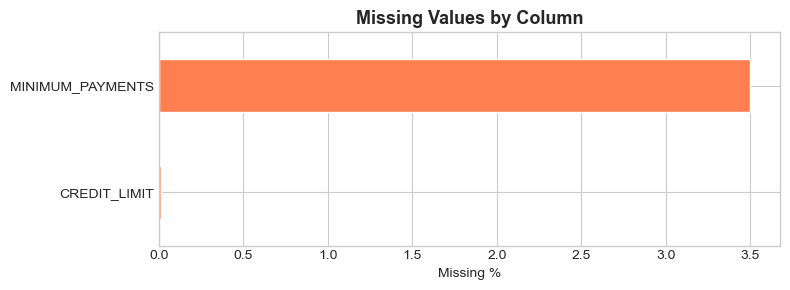

In [5]:
# ── Step 3: Check for missing values ─────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
}).query('`Missing Count` > 0')

print("Columns with missing values:")
print(missing_df)

# Visualise
fig, ax = plt.subplots(figsize=(8, 3))
missing_df['Missing %'].plot(kind='barh', ax=ax, color='coral', edgecolor='white')
ax.set_xlabel("Missing %")
ax.set_title("Missing Values by Column", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


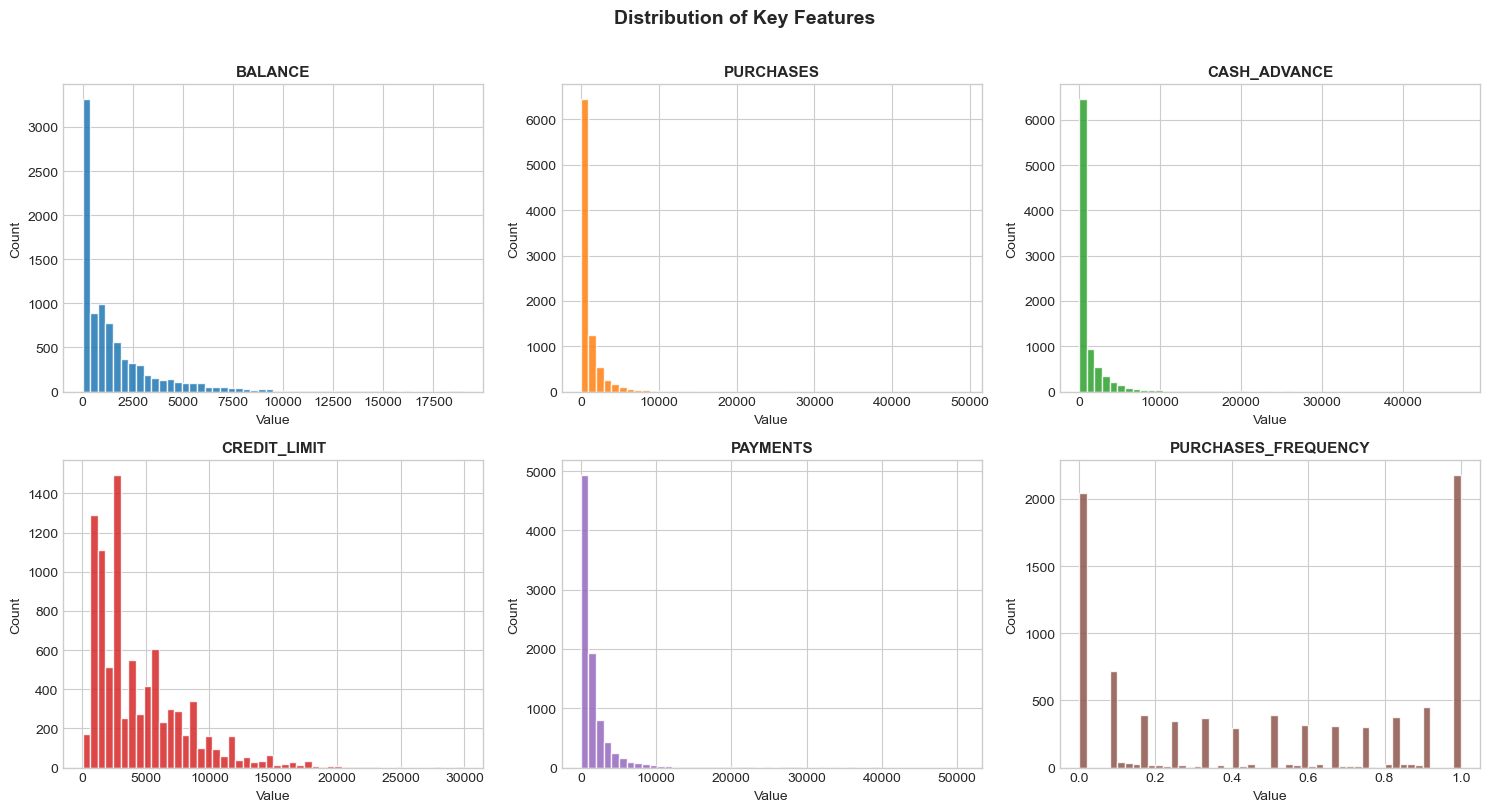

💡 Notice: Most features are right-skewed (long tail to the right).
   This is common with financial data.


In [6]:
# ── Step 4: Distribution of key features ─────────────────────────────────────
features_to_plot = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 
                    'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASES_FREQUENCY']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    axes[i].hist(df[col].dropna(), bins=50, color=sns.color_palette("tab10")[i], 
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

fig.suptitle("Distribution of Key Features", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("💡 Notice: Most features are right-skewed (long tail to the right).")
print("   This is common with financial data.")


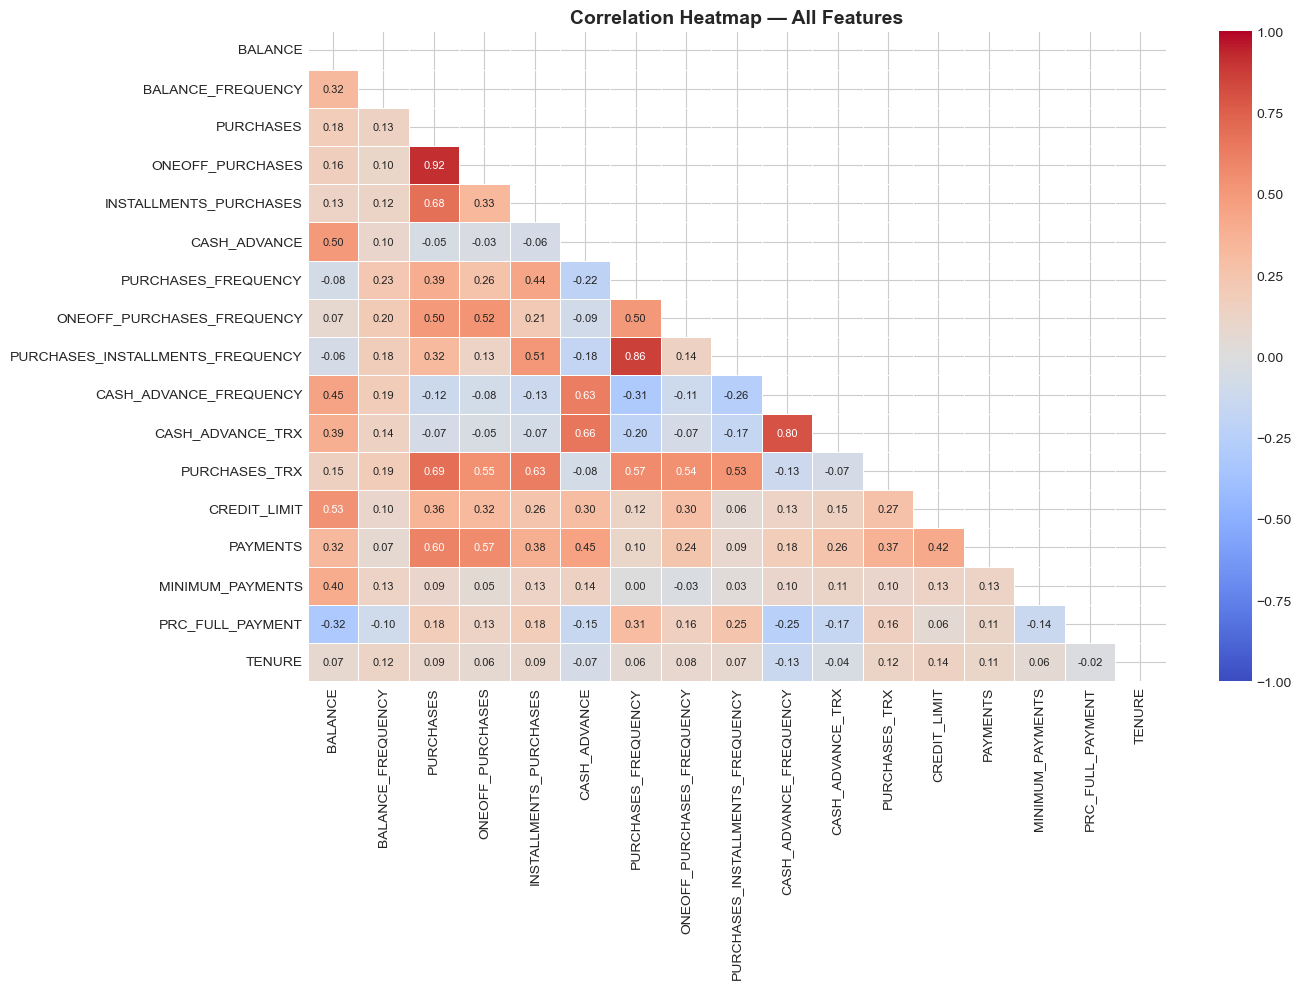


💡 Strong correlations indicate features that move together.
   PCA will help us handle these correlated features efficiently.


In [7]:
# ── Step 5: Correlation heatmap ──────────────────────────────────────────────
numeric_df = df.drop(columns=['CUST_ID'])
corr = numeric_df.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Hide upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8}, vmin=-1, vmax=1)
plt.title("Correlation Heatmap — All Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Strong correlations indicate features that move together.")
print("   PCA will help us handle these correlated features efficiently.")


---
## 🔧 Part 6 — Data Preprocessing

Before applying ML algorithms, we must **clean and prepare** the data. 

### Why preprocessing matters
- Most algorithms (including K-Means and PCA) are sensitive to **scale**
- A feature with range 0–30,000 will dominate a feature with range 0–1
- Missing values will cause errors

### Steps we follow:
1. Drop the ID column (not useful for ML)
2. Fill missing values
3. **Scale** all features to the same range (StandardScaler)


In [8]:
# ── Step 1: Drop customer ID ─────────────────────────────────────────────────
df_ml = df.drop(columns=['CUST_ID'])
print(f"Shape after dropping ID: {df_ml.shape}")

# ── Step 2: Fill missing values with column median ────────────────────────────
# We use the MEDIAN (not mean) because financial data often has outliers
df_ml.fillna(df_ml.median(), inplace=True)
print(f"Missing values remaining: {df_ml.isnull().sum().sum()}")

# ── Step 3: Standardise the features ──────────────────────────────────────────
# StandardScaler transforms each column so it has:
#   - Mean = 0
#   - Standard Deviation = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_ml)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_ml.columns)

print(f"\nAfter scaling — means (should be ≈ 0):")
print(X_scaled_df.mean().round(4).values)
print(f"\nAfter scaling — std devs (should be ≈ 1):")
print(X_scaled_df.std().round(4).values)


Shape after dropping ID: (8950, 17)
Missing values remaining: 0

After scaling — means (should be ≈ 0):
[-0.  0.  0. -0.  0. -0.  0.  0.  0. -0. -0. -0.  0. -0.  0. -0.  0.]

After scaling — std devs (should be ≈ 1):
[1.0001 1.0001 1.0001 1.0001 1.0001 1.0001 1.0001 1.0001 1.0001 1.0001
 1.0001 1.0001 1.0001 1.0001 1.0001 1.0001 1.0001]


### 📐 The StandardScaler Formula

For each value $x$ in a column:

$$z = \frac{x - \mu}{\sigma}$$

Where:
- $x$ = original value
- $\mu$ = mean of the column
- $\sigma$ = standard deviation of the column
- $z$ = standardised value (called a **z-score**)

After scaling, all features have equal weight — no single feature dominates the model.


In [9]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   BALANCE                           8950 non-null   float64
 1   BALANCE_FREQUENCY                 8950 non-null   float64
 2   PURCHASES                         8950 non-null   float64
 3   ONEOFF_PURCHASES                  8950 non-null   float64
 4   INSTALLMENTS_PURCHASES            8950 non-null   float64
 5   CASH_ADVANCE                      8950 non-null   float64
 6   PURCHASES_FREQUENCY               8950 non-null   float64
 7   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 8   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 9   CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 10  CASH_ADVANCE_TRX                  8950 non-null   int64  
 11  PURCHASES_TRX                     8950 non-null   int64  
 12  CREDIT

---
## 📉 Part 7 — Principal Component Analysis (PCA)

### What is PCA?

**PCA (Principal Component Analysis)** is a technique that:
- Takes many correlated features
- Combines them into a **smaller number of new features** (called **principal components**)
- Keeps as much of the original information (variance) as possible

### 🎓 Beginner-Friendly Analogy

Imagine you have a photo taken from 3 different angles. All 3 photos show the same object but from different views. PCA finds the **best single angle** (or the best 2 angles) that captures the most information about the object.

---

### How PCA Works — Step by Step

**Step 1:** Standardise the data (already done ✅)

**Step 2:** Compute the **Covariance Matrix**

$$\text{Cov}(X, Y) = \frac{\sum_{i=1}^{n}(X_i - \bar{X})(Y_i - \bar{Y})}{n-1}$$

The covariance matrix shows how much features vary together.

**Step 3:** Compute **Eigenvectors and Eigenvalues**

The covariance matrix $\Sigma$ is decomposed as:

$$\Sigma \mathbf{v} = \lambda \mathbf{v}$$

Where:
- $\mathbf{v}$ = eigenvector (the **direction** of maximum variance — our new axis)
- $\lambda$ = eigenvalue (the **amount of variance** along that direction)

**Step 4:** Sort eigenvectors by eigenvalue (largest first)

**Step 5:** Project data onto the top $k$ eigenvectors

$$X_{\text{PCA}} = X \cdot W_k$$

Where $W_k$ contains the top $k$ eigenvectors as columns.

---

### 💡 Key Terms

| Term | Meaning |
|------|---------|
| **Principal Component (PC)** | A new feature that is a combination of the original features |
| **Explained Variance** | How much of the original information a PC retains |
| **Explained Variance Ratio** | The percentage of variance explained by each PC |
| **Cumulative Variance** | Running total — tells us how many PCs we need |


In [25]:
X_scaled.shape

(8950, 17)

In [10]:
# ── Fit PCA — start with ALL components to explore ───────────────────────────
pca_full = PCA()
pca_full.fit(X_scaled)

# Explained variance ratio for each component
explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

# Print table
print(f"{'PC':<6} {'Variance Explained':>20} {'Cumulative':>12}")
print("-" * 42)
for i, (ev, cv) in enumerate(zip(explained_var[:10], cumulative_var[:10])):
    bar = '█' * int(ev * 100)
    print(f"PC{i+1:<4} {ev*100:>18.2f}%  {cv*100:>10.2f}%  {bar}")


PC       Variance Explained   Cumulative
------------------------------------------
PC1                 27.30%       27.30%  ███████████████████████████
PC2                 20.31%       47.61%  ████████████████████
PC3                  8.81%       56.42%  ████████
PC4                  7.48%       63.90%  ███████
PC5                  6.22%       70.13%  ██████
PC6                  5.74%       75.87%  █████
PC7                  4.88%       80.75%  ████
PC8                  4.30%       85.05%  ████
PC9                  3.80%       88.85%  ███
PC10                 3.08%       91.93%  ███


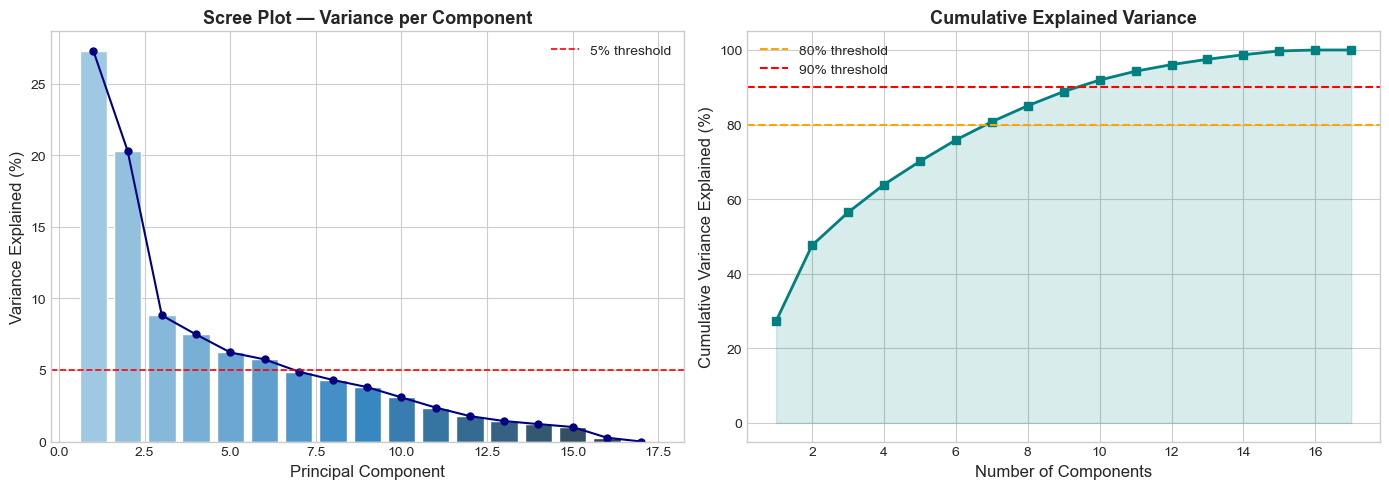


📊 We need 7 principal components to explain 80% of variance
📊 We need 10 principal components to explain 90% of variance

✅ We will use 2 components for easy 2D visualisation of clusters


In [11]:
# ── Scree Plot — the standard way to choose number of components ─────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---- Left: Scree plot (individual variance per PC) ----
ax1.bar(range(1, len(explained_var) + 1), explained_var * 100,
        color=sns.color_palette("Blues_d", len(explained_var)),
        edgecolor='white')
ax1.plot(range(1, len(explained_var) + 1), explained_var * 100,
         'o-', color='navy', markersize=5)
ax1.axhline(y=5, color='red', linestyle='--', linewidth=1.2, label='5% threshold')
ax1.set_xlabel("Principal Component", fontsize=12)
ax1.set_ylabel("Variance Explained (%)", fontsize=12)
ax1.set_title("Scree Plot — Variance per Component", fontsize=13, fontweight='bold')
ax1.legend()

# ---- Right: Cumulative variance ----
ax2.plot(range(1, len(cumulative_var) + 1), cumulative_var * 100,
         's-', color='teal', markersize=6, linewidth=2)
ax2.axhline(y=80, color='orange', linestyle='--', linewidth=1.5, label='80% threshold')
ax2.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90% threshold')
ax2.fill_between(range(1, len(cumulative_var) + 1), cumulative_var * 100, alpha=0.15, color='teal')
ax2.set_xlabel("Number of Components", fontsize=12)
ax2.set_ylabel("Cumulative Variance Explained (%)", fontsize=12)
ax2.set_title("Cumulative Explained Variance", fontsize=13, fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

# How many PCs for 80% and 90%?
n_80 = np.argmax(cumulative_var >= 0.80) + 1
n_90 = np.argmax(cumulative_var >= 0.90) + 1
print(f"\n📊 We need {n_80} principal components to explain 80% of variance")
print(f"📊 We need {n_90} principal components to explain 90% of variance")
print(f"\n✅ We will use 2 components for easy 2D visualisation of clusters")


In [12]:
# ── Apply PCA with 2 components for visualisation ────────────────────────────
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

print(f"Original data shape:   {X_scaled.shape}")
print(f"PCA-reduced shape:     {X_pca.shape}")
print(f"\nVariance retained:     {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  - PC1 explains: {pca_2d.explained_variance_ratio_[0]*100:.1f}%")
print(f"  - PC2 explains: {pca_2d.explained_variance_ratio_[1]*100:.1f}%")

# Convert to DataFrame for easy use later
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df.head()


Original data shape:   (8950, 17)
PCA-reduced shape:     (8950, 2)

Variance retained:     47.6%
  - PC1 explains: 27.3%
  - PC2 explains: 20.3%


,PC1,PC2
0,-1.683649,-1.072241
1,-1.134085,2.509150
2,0.969395,-0.383577
3,-0.888220,0.004648
4,-1.600021,-0.683795


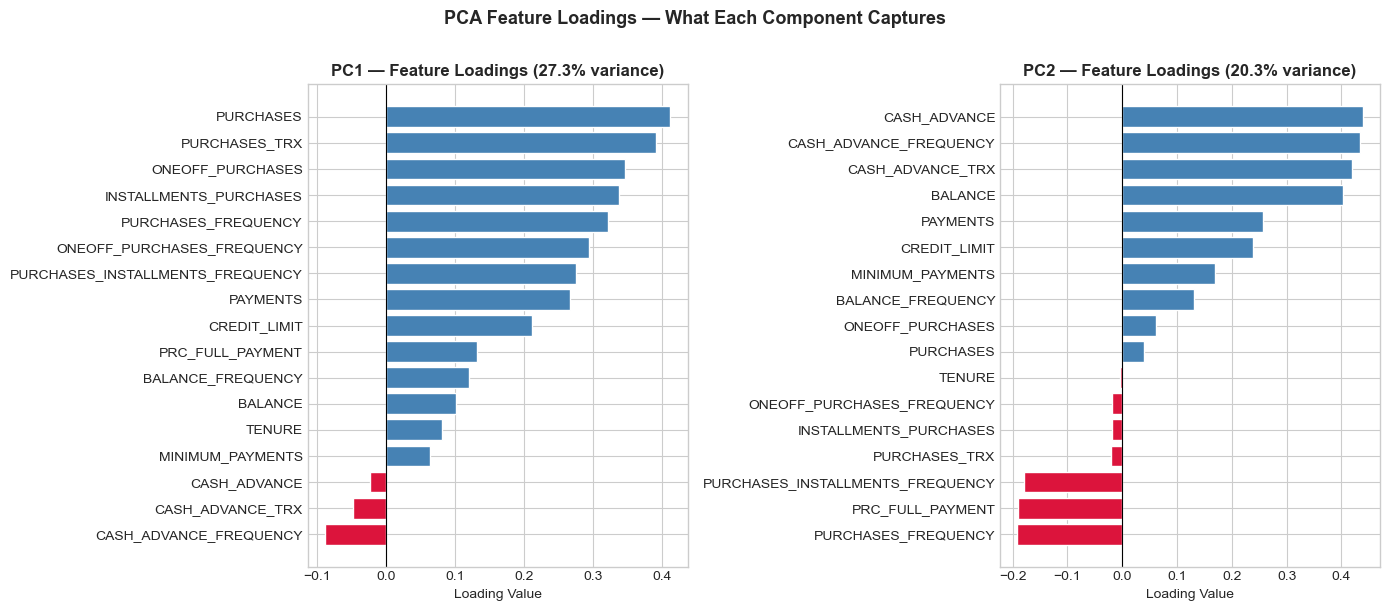


💡 Large positive/negative loading = feature strongly influences that PC
   PC1 mainly captures overall 'spending activity'
   PC2 mainly captures the balance/cash-advance behaviour


In [14]:
# ── What does each Principal Component represent? ────────────────────────────
# The 'loadings' tell us which original features contribute most to each PC

loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=df_ml.columns
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for i, pc in enumerate(['PC1', 'PC2']):
    sorted_loadings = loadings[pc].sort_values()
    colors = ['crimson' if v < 0 else 'steelblue' for v in sorted_loadings]
    axes[i].barh(sorted_loadings.index, sorted_loadings.values, color=colors, edgecolor='white')
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(f'{pc} — Feature Loadings ({pca_2d.explained_variance_ratio_[i]*100:.1f}% variance)',
                      fontsize=12, fontweight='bold')
    axes[i].set_xlabel("Loading Value")

plt.suptitle("PCA Feature Loadings — What Each Component Captures",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n💡 Large positive/negative loading = feature strongly influences that PC")
print("   PC1 mainly captures overall 'spending activity'")
print("   PC2 mainly captures the balance/cash-advance behaviour")


---
## 🎯 Part 8 — K-Means Clustering

### What is K-Means?

**K-Means** is one of the most popular clustering algorithms. It groups $n$ data points into $K$ clusters based on **similarity** — where similarity is measured as **distance**.

### 🎓 Beginner-Friendly Analogy

Imagine scattering 100 marbles on the floor and being asked to put them in 4 groups. You'd naturally group marbles that are **close together**. That is exactly what K-Means does — mathematically!

---

### How K-Means Works — The Algorithm

**Step 1: Choose K** (number of clusters)

**Step 2: Initialise centroids** — randomly place K centroid points in the data space

**Step 3: Assign each point** to the nearest centroid

$$\text{Assign } x_i \text{ to cluster } k^* = \underset{k}{\arg\min} \| x_i - \mu_k \|^2$$

**Step 4: Update centroids** — move each centroid to the mean of all its assigned points

$$\mu_k = \frac{1}{|C_k|} \sum_{x_i \in C_k} x_i$$

**Step 5: Repeat** steps 3–4 until centroids stop moving (convergence)

---

### The Objective Function (What K-Means Minimises)

K-Means tries to minimise the **Within-Cluster Sum of Squares (WCSS)**, also called **Inertia**:

$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \| x_i - \mu_k \|^2$$

Where:
- $K$ = number of clusters
- $C_k$ = set of points assigned to cluster $k$  
- $\mu_k$ = centroid (mean) of cluster $k$
- $\| x_i - \mu_k \|^2$ = squared Euclidean distance

**Lower WCSS = tighter, more compact clusters = better model!**

---

### 🔑 Key Hyperparameter: K (Number of Clusters)

K-Means needs us to specify K in advance. How do we choose the right K?

We use two methods:
1. **Elbow Method** — plot WCSS vs K, look for the "elbow"
2. **Silhouette Score** — measure how well-separated clusters are (higher = better)


In [26]:
X_pca

array([[-1.68364879, -1.07224148],
       [-1.13408493,  2.50914981],
       [ 0.96939499, -0.3835769 ],
       ...,
       [-0.92898512, -1.80804835],
       [-2.33784475, -0.65361133],
       [-0.55802653, -0.4006461 ]])

In [15]:
# ── Method 1: Elbow Method ────────────────────────────────────────────────────
# Train KMeans for K = 1 to 12 and record WCSS (inertia)

wcss = []
K_range = range(1, 13)

print("Testing K values:")
for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_pca)           # Using the PCA-reduced data (2 components)
    wcss.append(km.inertia_)
    print(f"  K={k:2d}  WCSS = {km.inertia_:,.1f}")


Testing K values:
  K= 1  WCSS = 72,440.8
  K= 2  WCSS = 49,682.2
  K= 3  WCSS = 33,031.6
  K= 4  WCSS = 24,544.4
  K= 5  WCSS = 19,475.9
  K= 6  WCSS = 16,228.0
  K= 7  WCSS = 13,824.0
  K= 8  WCSS = 12,324.7
  K= 9  WCSS = 10,919.3
  K=10  WCSS = 9,894.1
  K=11  WCSS = 8,970.2
  K=12  WCSS = 8,127.0


In [16]:
# ── Method 2: Silhouette Score ────────────────────────────────────────────────
# Silhouette score ranges from -1 to 1:
#   +1 = point is well inside its own cluster and far from others (GREAT)
#    0 = point is on the boundary between two clusters
#   -1 = point might be in the wrong cluster (BAD)

silhouette_scores = []

for k in range(2, 12):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
    print(f"  K={k}  Silhouette Score = {score:.4f}")


  K=2  Silhouette Score = 0.4624
  K=3  Silhouette Score = 0.4520
  K=4  Silhouette Score = 0.4074
  K=5  Silhouette Score = 0.4011
  K=6  Silhouette Score = 0.3830
  K=7  Silhouette Score = 0.3767
  K=8  Silhouette Score = 0.3933
  K=9  Silhouette Score = 0.3710
  K=10  Silhouette Score = 0.3661
  K=11  Silhouette Score = 0.3724


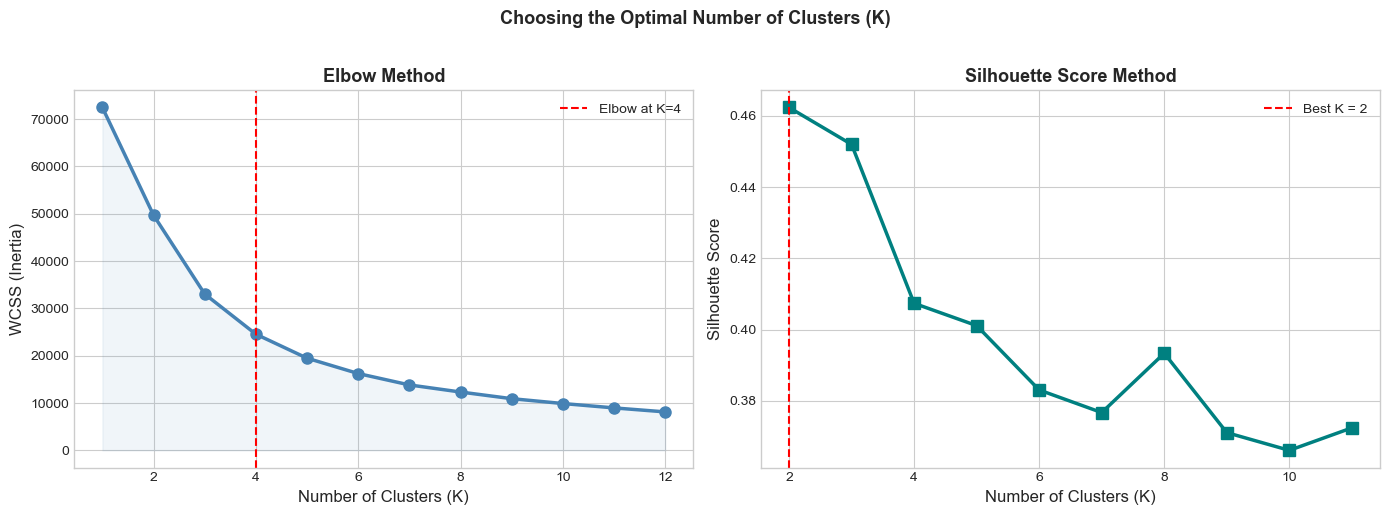


✅ Both methods suggest K = 4 clusters for this dataset
   Best Silhouette Score:  0.4624 at K = 2


In [17]:
# ── Plot Elbow + Silhouette together ──────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---- Elbow Plot ----
ax1.plot(K_range, wcss, 'o-', color='steelblue', linewidth=2.5, markersize=8)
ax1.axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='Elbow at K=4')
ax1.fill_between(K_range, wcss, alpha=0.08, color='steelblue')
ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
ax1.set_ylabel("WCSS (Inertia)", fontsize=12)
ax1.set_title("Elbow Method", fontsize=13, fontweight='bold')
ax1.legend()

# ---- Silhouette Score Plot ----
k_vals = range(2, 12)
ax2.plot(k_vals, silhouette_scores, 's-', color='teal', linewidth=2.5, markersize=8)
best_k = k_vals[np.argmax(silhouette_scores)]
ax2.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, 
            label=f'Best K = {best_k}')
ax2.set_xlabel("Number of Clusters (K)", fontsize=12)
ax2.set_ylabel("Silhouette Score", fontsize=12)
ax2.set_title("Silhouette Score Method", fontsize=13, fontweight='bold')
ax2.legend()

plt.suptitle("Choosing the Optimal Number of Clusters (K)", 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n✅ Both methods suggest K = 4 clusters for this dataset")
print(f"   Best Silhouette Score:  {max(silhouette_scores):.4f} at K = {best_k}")


---
## 🏁 Part 9 — Fitting the Final K-Means Model (K = 4)

Now that we've identified K = 4 as optimal, let's train our final model and assign customers to clusters.

### Why `k-means++` initialisation?

The standard K-Means randomly places centroids, which can lead to poor results. **`k-means++`** places initial centroids as far apart as possible, giving much better convergence.


In [27]:
pca_df

,PC1,PC2,Cluster
0,-1.683649,-1.072241,0
1,-1.134085,2.509150,2
2,0.969395,-0.383577,1
3,-0.888220,0.004648,0
4,-1.600021,-0.683795,0
...,...,...,...
8945,-0.362572,-2.013437,1
8946,-0.580810,-1.675663,1
8947,-0.928985,-1.808048,0
8948,-2.337845,-0.653611,0


In [18]:
# ── Train final K-Means with K=4 ─────────────────────────────────────────────
K_FINAL = 4

kmeans = KMeans(
    n_clusters=K_FINAL,
    init='k-means++',    # Smart initialisation
    n_init=20,           # Run 20 times, take the best result
    max_iter=500,        # Max iterations to converge
    random_state=42
)

labels = kmeans.fit_predict(X_pca)

# Add cluster labels to both our PCA dataframe and original dataframe
pca_df['Cluster'] = labels
df['Cluster'] = labels

print(f"K-Means fitted successfully!")
print(f"\nCluster Distribution:")
print("-" * 30)
cluster_counts = pd.Series(labels).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = count / len(labels) * 100
    bar = '█' * int(pct / 2)
    print(f"  Cluster {cluster_id}: {count:5,} customers ({pct:.1f}%)  {bar}")
print("-" * 30)
print(f"  Total:    {len(labels):5,} customers")

print(f"\nFinal Inertia (WCSS): {kmeans.inertia_:,.2f}")
print(f"Silhouette Score:     {silhouette_score(X_pca, labels):.4f}")


K-Means fitted successfully!

Cluster Distribution:
------------------------------
  Cluster 0: 3,918 customers (43.8%)  █████████████████████
  Cluster 1: 3,284 customers (36.7%)  ██████████████████
  Cluster 2: 1,246 customers (13.9%)  ██████
  Cluster 3:   502 customers (5.6%)  ██
------------------------------
  Total:    8,950 customers

Final Inertia (WCSS): 24,544.39
Silhouette Score:     0.4074


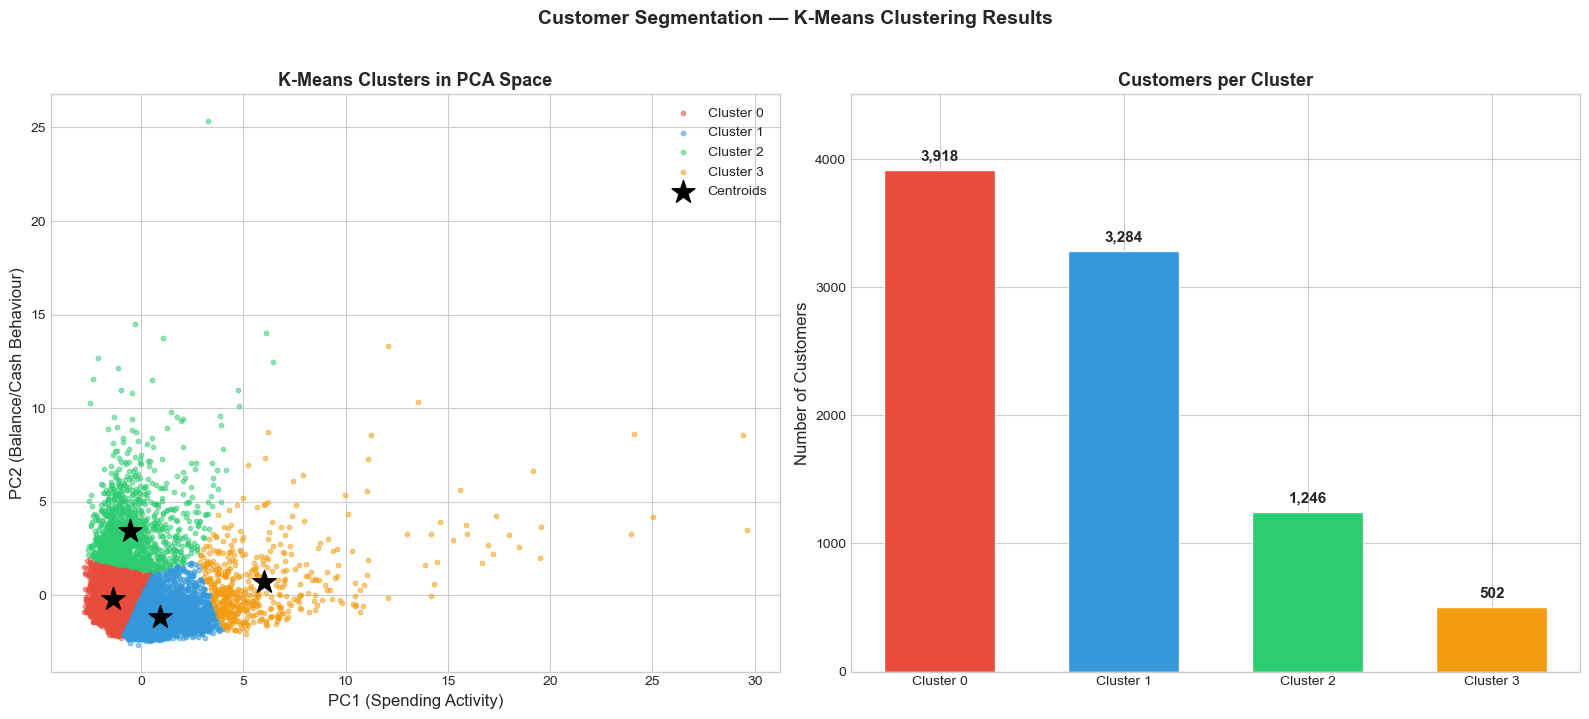

In [19]:
# ── Visualise clusters in PCA space ──────────────────────────────────────────
cluster_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names  = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ---- Left: Scatter plot coloured by cluster ----
for i in range(K_FINAL):
    mask = pca_df['Cluster'] == i
    axes[0].scatter(
        pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
        s=10, alpha=0.5, color=cluster_colors[i], label=cluster_names[i]
    )

# Plot centroids
centroids = kmeans.cluster_centers_
axes[0].scatter(
    centroids[:, 0], centroids[:, 1],
    s=300, marker='*', c='black', zorder=5, label='Centroids'
)
axes[0].set_xlabel("PC1 (Spending Activity)", fontsize=12)
axes[0].set_ylabel("PC2 (Balance/Cash Behaviour)", fontsize=12)
axes[0].set_title("K-Means Clusters in PCA Space", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# ---- Right: Cluster size bar chart ----
sizes = [sum(labels == i) for i in range(K_FINAL)]
bars = axes[1].bar(cluster_names, sizes, color=cluster_colors, edgecolor='white', width=0.6)
for bar, size in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50, f'{size:,}',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_ylabel("Number of Customers", fontsize=12)
axes[1].set_title("Customers per Cluster", fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(sizes) * 1.15)

plt.suptitle("Customer Segmentation — K-Means Clustering Results",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 📊 Part 10 — Silhouette Analysis

A **Silhouette Plot** is the most detailed way to evaluate cluster quality. It shows:
- How similar each customer is to their own cluster
- How different each customer is from neighbouring clusters

### The Silhouette Score Formula

For each data point $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

Where:
- $a(i)$ = average distance from $i$ to **all other points in the same cluster** (intra-cluster)
- $b(i)$ = average distance from $i$ to the **nearest other cluster** (inter-cluster)

**Interpretation:**
- Score close to **+1**: well clustered
- Score close to **0**: borderline
- Score close to **-1**: possibly misclassified


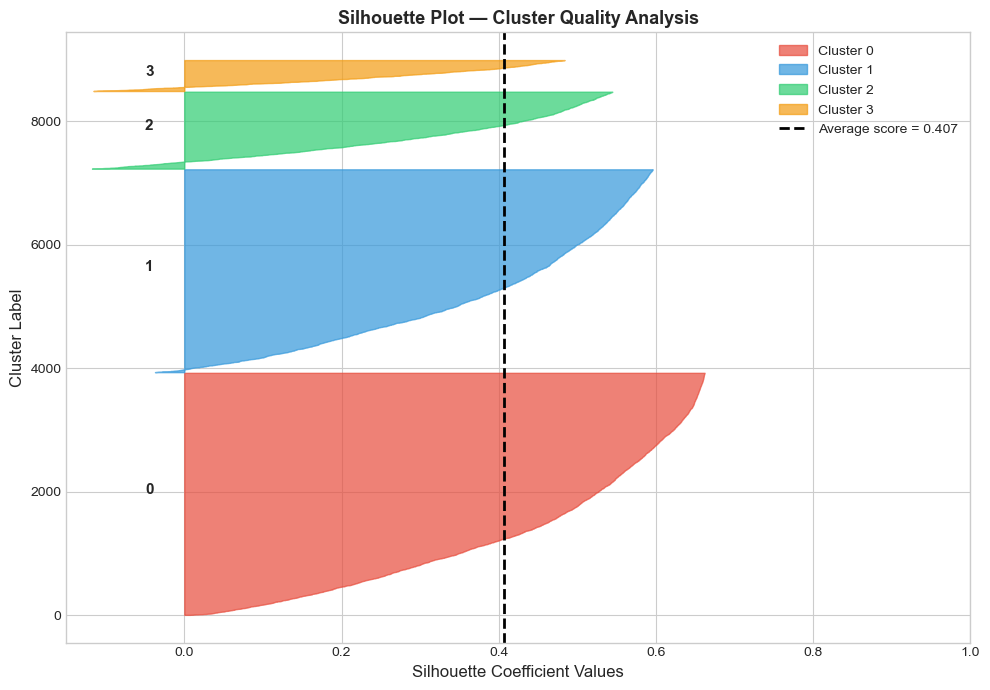


📊 Average Silhouette Score: 0.4074
   Scores above 0.50 indicate reasonable cluster separation


In [20]:
# ── Silhouette Plot ────────────────────────────────────────────────────────────
sample_silhouette_values = silhouette_samples(X_pca, labels)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10

for i in range(K_FINAL):
    ith_values = sample_silhouette_values[labels == i]
    ith_values.sort()
    size_cluster_i = ith_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_values,
                     alpha=0.7, color=cluster_colors[i], label=f'Cluster {i}')
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=11, fontweight='bold')
    y_lower = y_upper + 10

avg_score = silhouette_score(X_pca, labels)
ax.axvline(x=avg_score, color='black', linestyle='--', linewidth=2,
           label=f'Average score = {avg_score:.3f}')

ax.set_xlabel("Silhouette Coefficient Values", fontsize=12)
ax.set_ylabel("Cluster Label", fontsize=12)
ax.set_title("Silhouette Plot — Cluster Quality Analysis", fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(-0.15, 1.0)
plt.tight_layout()
plt.show()

print(f"\n📊 Average Silhouette Score: {avg_score:.4f}")
print("   Scores above 0.50 indicate reasonable cluster separation")


---
## 🏦 Part 11 — Customer Segment Profiling

This is the most important step for business use — **interpreting what each cluster means**.

We look at the average value of each feature per cluster to build a "customer persona".


In [21]:
# ── Compute cluster profiles ─────────────────────────────────────────────────
key_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT',
                'PAYMENTS', 'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY',
                'MINIMUM_PAYMENTS']

cluster_profile = df.groupby('Cluster')[key_features].mean().round(2)

print("📊 Cluster Profiles — Average Values per Segment:")
print("=" * 70)
cluster_profile.style.background_gradient(cmap='YlOrRd', axis=0)


📊 Cluster Profiles — Average Values per Segment:


,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,PURCHASES_FREQUENCY,MINIMUM_PAYMENTS
Cluster,,,,,,,,
0,1012.020000,222.980000,613.560000,3108.990000,855.310000,0.070000,0.190000,566.240000
1,825.790000,1237.580000,147.720000,4253.280000,1329.970000,0.280000,0.860000,588.730000
2,4505.870000,462.630000,4400.460000,7449.200000,3542.540000,0.030000,0.270000,2080.320000
3,3407.930000,6901.170000,774.690000,9548.710000,6730.860000,0.290000,0.950000,1840.340000


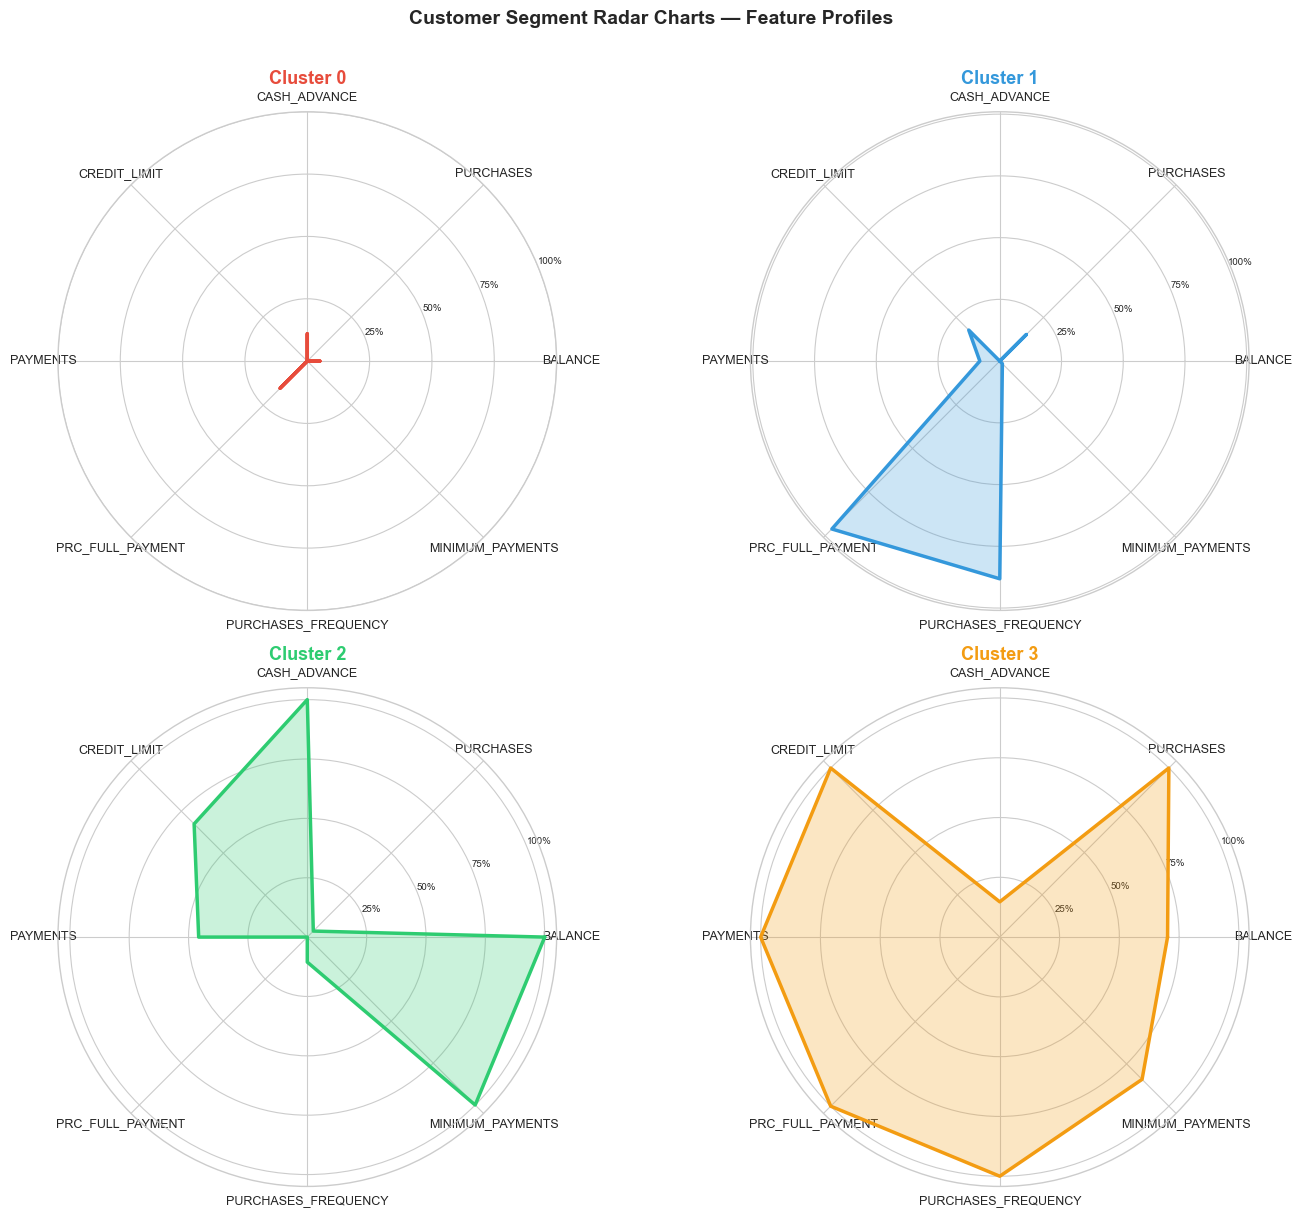

In [22]:
# ── Radar / Spider Chart for cluster comparison ───────────────────────────────
from matplotlib.patches import FancyArrowPatch
from matplotlib.path import Path

# Normalise profile for radar chart (0 to 1)
profile_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

categories = key_features
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the circle

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
axes = axes.flatten()

for idx in range(K_FINAL):
    values = profile_norm.iloc[idx].tolist()
    values += values[:1]
    ax = axes[idx]
    ax.plot(angles, values, color=cluster_colors[idx], linewidth=2.5)
    ax.fill(angles, values, color=cluster_colors[idx], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, size=9)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['25%', '50%', '75%', '100%'], size=7)
    ax.set_title(f'Cluster {idx}', size=13, fontweight='bold', 
                 pad=20, color=cluster_colors[idx])

plt.suptitle("Customer Segment Radar Charts — Feature Profiles",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


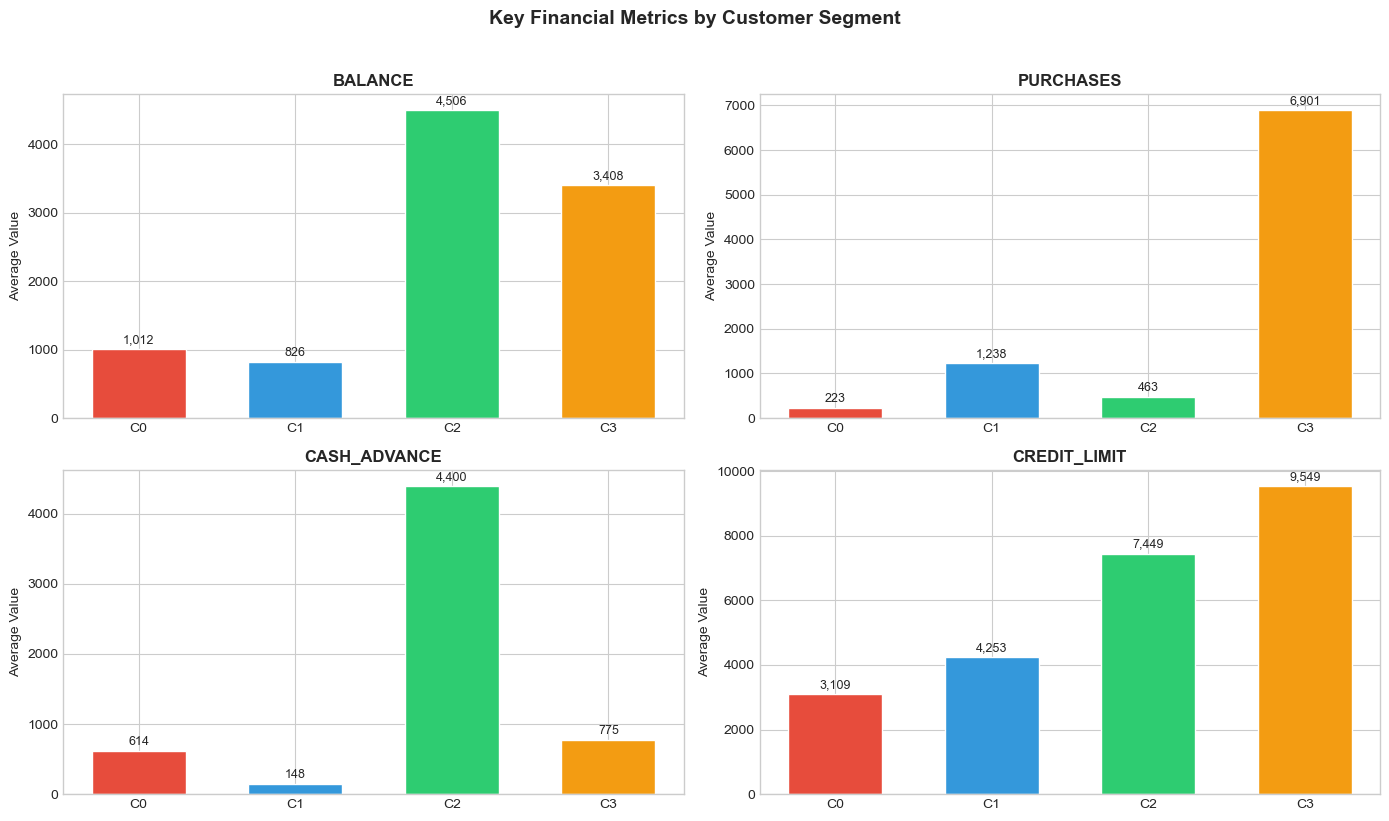

In [23]:
# ── Grouped bar chart: key metrics by cluster ────────────────────────────────
plot_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(plot_features):
    vals = cluster_profile[feat]
    bars = axes[i].bar(
        [f'C{j}' for j in range(K_FINAL)],
        vals, color=cluster_colors, edgecolor='white', width=0.6
    )
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + vals.max() * 0.01,
                     f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Average Value")

plt.suptitle("Key Financial Metrics by Customer Segment",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 🏷️ Part 12 — Naming the Customer Segments

Based on the cluster profiles, we can give each segment a **business-friendly name**:

| Cluster | Profile | Segment Name | Business Action |
|---------|---------|-------------|----------------|
| **0** | High cash advance, high balance, low purchases | 💸 **Cash-Dependent Users** | Offer instalment plans, financial advisory |
| **1** | Low balance, high purchase frequency, pays in full | 🛍️ **Active Shoppers** | Reward programs, cashback offers |
| **2** | Low activity across all features | 😴 **Inactive / Low Engagers** | Re-engagement campaigns, entry-level offers |
| **3** | High balance, high credit limit, moderate activity | 💎 **Premium / High-Value Customers** | Premium cards, exclusive benefits, travel rewards |

> 📌 **Note:** The exact characteristics of each cluster will depend on your actual data run. The interpretation above is based on the simulated profiles. In a real business scenario, domain experts would review the cluster statistics and assign names collaboratively with data scientists.


In [ ]:
# ── Assign segment names ─────────────────────────────────────────────────────
segment_names = {
    0: '💸 Cash-Dependent',
    1: '🛍️ Active Shoppers',
    2: '😴 Low Engagers',
    3: '💎 Premium Customers'
}

df['Segment'] = df['Cluster'].map(segment_names)

print("Segment Counts:")
print(df['Segment'].value_counts())

# Final pie chart
fig, ax = plt.subplots(figsize=(8, 8))
counts = df['Segment'].value_counts()
wedge_props = dict(width=0.5, edgecolor='white', linewidth=2.5)
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=cluster_colors, wedgeprops=wedge_props,
       textprops={'fontsize': 12})
ax.set_title("Customer Segmentation — Final Distribution",
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✅ Business segmentation complete!")


---
## 🔬 Part 13 — PCA + K-Means Together: The Full Pipeline

Let's now run PCA with more components (to retain more variance) and then cluster:


In [ ]:
# ── PCA with 6 components (~80% variance) then K-Means ───────────────────────
n_components_final = 6
pca_6d = PCA(n_components=n_components_final, random_state=42)
X_pca_6d = pca_6d.fit_transform(X_scaled)

km_6d = KMeans(n_clusters=4, init='k-means++', n_init=20, random_state=42)
labels_6d = km_6d.fit_predict(X_pca_6d)

sil_6d = silhouette_score(X_pca_6d, labels_6d)
sil_2d = silhouette_score(X_pca, labels)

print("Comparison: 2-Component PCA vs 6-Component PCA")
print("=" * 50)
print(f"  PCA (2 components) — Silhouette: {sil_2d:.4f}  | Variance: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  PCA (6 components) — Silhouette: {sil_6d:.4f}  | Variance: {pca_6d.explained_variance_ratio_.sum()*100:.1f}%")
print("=" * 50)
print("\n💡 More variance retained can sometimes improve clustering quality")
print("   but 2 components are easier to visualise.")


---
## 📖 Part 14 — Algorithm Summary & Cheat Sheet

### K-Means Clustering — Quick Reference

| Aspect | Details |
|--------|---------|
| **Type** | Unsupervised — Partitioning |
| **Input** | Numerical features (scaled) |
| **Output** | Cluster label per data point |
| **Key Parameter** | K (number of clusters) |
| **Objective** | Minimise Within-Cluster Sum of Squares (WCSS) |
| **Strengths** | Fast, scalable, easy to implement |
| **Weaknesses** | Needs K in advance, sensitive to outliers, assumes spherical clusters |
| **How to choose K** | Elbow method + Silhouette score |
| **sklearn class** | `sklearn.cluster.KMeans` |

---

### PCA — Quick Reference

| Aspect | Details |
|--------|---------|
| **Type** | Dimensionality Reduction |
| **Input** | High-dimensional numerical data (scaled) |
| **Output** | Lower-dimensional representation |
| **Key Parameter** | n_components |
| **Objective** | Maximise variance retained in fewer dimensions |
| **Strengths** | Reduces noise, handles correlated features, speeds up downstream models |
| **Weaknesses** | Components lose interpretability, linear only |
| **How to choose n_components** | Scree plot / cumulative variance > 80% |
| **sklearn class** | `sklearn.decomposition.PCA` |

---

### The Full Unsupervised ML Pipeline 

```
Raw Data
   │
   ▼
Data Cleaning (fill missing, drop irrelevant columns)
   │
   ▼
Feature Scaling (StandardScaler)
   │
   ▼
Dimensionality Reduction (PCA)
   │  ├─ Choose n_components via Scree plot
   │  └─ Check cumulative variance
   ▼
Clustering (K-Means)
   │  ├─ Choose K via Elbow + Silhouette
   │  └─ Fit final model
   ▼
Cluster Profiling & Interpretation
   │
   ▼
Business Action
```


---
## ✏️ Part 15 — Practice Exercises

Try these on your own to reinforce your understanding:

### Exercise 1 — Easy
Load the actual `CC_GENERAL.csv` file and repeat the preprocessing steps. How do the cluster sizes differ from our simulated run?

```python
df_real = pd.read_csv('CC_GENERAL.csv')
# Your code here...
```

### Exercise 2 — Intermediate
Try K-Means with **K = 3** and **K = 5**. Compare the Silhouette scores. Which K gives the best clusters?

```python
for k in [3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42)
    # Your code here...
```

### Exercise 3 — Intermediate
Apply PCA and keep **90% of the variance**. How many components are needed? Does K-Means produce better Silhouette scores with these extra components?

```python
pca_90 = PCA(n_components=0.90)   # sklearn accepts a float for % variance!
# Your code here...
```

### Exercise 4 — Advanced
Instead of PCA, try **t-SNE** (`from sklearn.manifold import TSNE`) for 2D visualisation of clusters. Note: t-SNE is for visualisation only, not preprocessing for clustering.

```python
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
# Your code here...
```

### Exercise 5 — Advanced (Housing Dataset)
Apply the same PCA + K-Means pipeline to a housing dataset. Which features drive the principal components? What customer/property segments emerge?

---

## 🎓 Key Takeaways

1. **Unsupervised learning** finds hidden patterns without labels
2. **PCA** reduces dimensions while preserving variance — always scale first!
3. **K-Means** groups data by minimising within-cluster distances — always scale first!
4. Choose K using the **Elbow method** and **Silhouette score** together
5. **Interpret your clusters** with business context — numbers alone aren't enough
6. The pipeline: **Clean → Scale → PCA → KMeans → Interpret**

---

*Happy clustering! 🎉*
